In [1]:
include("/mnt/c/Users/flori/Documents/PostDoc/Jupyter/Julia/sivers/sivers.jl")

using .Sivers

In [2]:
# Check it vanishes for non spin-flip
# Takes about 4m30s
k = [0.1,0]
odderon_distribution(1,1,k,[0,0])

131478.724039888

In [16]:
function test_odderon_distribution(s01::Integer,s02::Integer,k::Vector{<:Real},Δ::Vector{<:Real})
    if !iszero(Δ)
        throw(ArgumentError("Implementation currently only for vanishing Δ."))
    end
    function integrand(x)
        # 6d input for cubic_color_corellator
        x6 = x[1:6]
        # 2d input for q2 integral
        x2 = x[7:8]
        # Cuba samples are [0,1]^n so we
        # transform to polar coordinates
        r2 = x2[1] / (1 - x2[1])  # r ∈ [0, ∞)
        ϕ2 = 2π * x2[2]          # φ ∈ [0, 2π)
        
        # Reconstruct momentum in polar coordinates
        q2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]

        # Jacobian
        dq2 = r2 / (1 - x2[1])^2
        dϕ = (2π)

        total = 0
        for s in (+1,-1)
            q1 = s * k
            q3 = - s * k - q2
            # Denominator excluding q1^2 = k^2
            q32 = sum(q3.^2)

            ccc_integrand = cubic_color_corellator(s01,s02,q1,q2,q3,x6)
            total += s * ccc_integrand / q32
        end
        # Denominator
        q22 = sum(q2 .^ 2)
        total /= q22
        res = real(total * dq2 * dϕ)
        return res
    end
    # integral, err = cuhre(integrand, 8, 1, atol=1e-12, rtol=1e-10);
    res = integrand(rand(8))
end

i = 0 
while i < 1000000
    tmp = test_odderon_distribution(1,1,[.1,0],[0,0])
    if abs(real(tmp)) > 1e-6 || abs(imag(tmp)) > 1e-6
        println(tmp)
    end
    i += 1
end

-10.039833006155321
-10095.32964647672
-80.04435437714119
5.4692123843335846e-6
-92.56886924940592
1.086898891638377e-6
-1.5064851306452947e-5
18570.54774593917
1.9798377208616097e-6
93.18379982608383
-218.55905319909462
-3.744801912311472e-5
0.20327183286116993
-1.4952861649536666
-8.106462449977963e-5
0.00028606976860581193
-13.727931356074155
0.00022137130682574045
1.3539792034170715
-17873.841330998726
-81.37996121592411
-143.9068920746839
138005.0731829315
6.870367026186619e-5
-0.18750300143287205
18.115605073684936
-4.179926854841843e-6
-0.0829156360303592
1325.1173180638668
-1.4880669620059056e-5
-1.2578310278015812e-6
-0.07944271445526915
-269.7428665649943
-0.02113572165564865
513.478966833319
-1244.538858431677
16.757021193783014
4953.212154129637
-74.11762401329534
-143.9481372937767
0.17209275012165132
3.9018339458335376
10.0101109642122
0.00028362932292812606
-0.0005384356515160655
-43.43248726296675
0.0013470956131071544
0.01477715659515973
6.353278046535153e-5
-0.0002840

LoadError: InterruptException:

In [3]:
# Check it vanishes for non spin-flip
# Takes about 4m30s
k = [0,0]
odderon_distribution(1,1,k,[0,0])

-0.0

In [56]:
# Check whether result is sufficiently small
q1 = [0,0]
i = 0
while i < 1000000
    q2 = rand(2)
    q3 = - q1 - q2
    x6 = rand(6)
    tmp = cubic_color_corellator(1,-1,q1,q2,q3,x6)
    if abs(real(tmp)) > 1e-10 || abs(imag(tmp)) > 1e-10
        println("q1,q2,q3")
        display(q1)
        display(q2)
        display(q3)
        println("x6 cuba sample")
        display(x6)
    end
    i += 1
end
# @time cubic_color_corellator(1,-1,q1,q2,q3,rand(6))

In [58]:
# Result is finite (up to implicit 1 / k^2 factor)
k = [0,0]
odderon_distribution(1,-1,k,[0,0])

-0.0

In [ ]:
# Takes about 4m30s
k = [0.1,0]
odderon_distribution(1,-1,k,[0,0])

47714.84882030474

In [ ]:
# alpha_s at approximately 1 GeV
alpha_s = .5
# Gluon sivers function at k
0.93827 * 3 * 47714.84882030474 / (8π^3 * alpha_s) * alpha_s^3

135.36395690208772

Things I have tried to speed up:
- Summation outside integrand and summing contributions obtained by cuhre slightly faster
- Summation inside integrand is slightly slower
- Parallelizing with CUBACORES actually takes longer
- No speed up with parallelization in general

In [ ]:
# if Threads.nthreads() == 1
#     error("Error: only one available thread. Restart jupyter server after using export JULIA_NUM_THREADS=n")
# end

# deltas = 0.0:0.1:3.0
# results = f1_form_factor_table(deltas)
# Takes 20:03 minutes when the sum is performed once inside the integrand
# Takes 19:57 minutes when each contribution is integrated separately and then summed

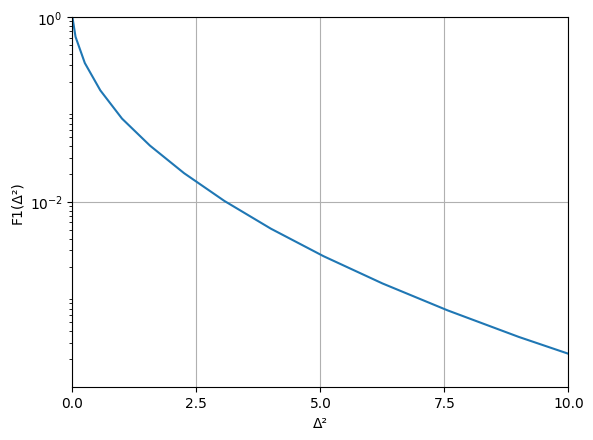

In [39]:
using PyPlot

plot(deltas.^2,results)
yscale("log")
xlim(0, 10)
ylim(1e-4,1)
xticks([0.0,2.5,5.0,7.5,10])
yticks([10^0, 10^-2])
xlabel("Δ²")
ylabel("F1(Δ²)")
grid(true)